In [ ]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('TkAgg') # This line was commented out as it causes an ImportError in a headless environment
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os
import time
import torch

Função para determinar os pontos não determinantes

In [ ]:
def no_dominated(pontos, cap=0):
   """
   Determina os pontos não dominados de Pareto

   Input:
   pontos = conjunto de pontos [f1 f2]

   Output:
   nd_pontos = pontos não dominados [f1* f2*]

   """

   # Marca o tempo de início
   inicio = time.perf_counter()

   # Seleciona a GPU caso esteja disponível (CUDA)
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


   N = pontos.shape[0] # quantidade  de pontos
   nd_pontos = []
   solucao = []
   temp = []
   peso_acum = 0

   #cria um matriz_gabarito com todas as combinações possíveis de itens (0 ou 1)
   total_itens = pow(2, N)
   matriz_gabarito = np.array([[[int(bit)] for bit in f"{i:0{N}b}"] for i in range(total_itens)])
   total_itens = 1 << N  # Total de 2^N combinações
    
   # Envia os pontos originais para a memória de vídeo (VRAM)
   pontos_tensor = torch.tensor(pontos, dtype=torch.float32, device=device)
   pontos_tensor = torch.tenso

   print(f"Total de combinações de itens (bruto 2^N): {total_itens}")

   #print(matriz_gabarito)
   item_validado = 0
   peso_acum = 0

   # faz a validação dos pesos de acordo com a capacidade
   while total_itens != item_validado:
      temp = []
      peso_acum = 0
      for k in range(N):
         if matriz_gabarito[item_validado][k] == 1:
            #if pontos[k][1] <= cap:
            #   if peso_acum + pontos[k][1] <= cap:
                  peso_acum += pontos[k][1]
                  temp.append(pontos[k])

      #if peso_acum > 0 and peso_acum <= cap:
      solucao.append(temp)

      item_validado += 1

   # retirar itens repetidos indevidamente
   vistos = set()
   solucao_unica = []
   for combinacao in solucao:
      chave = tuple(tuple(np.asarray(item).tolist()) for item in combinacao)
      if chave not in vistos:
         vistos.add(chave)
         solucao_unica.append(combinacao)

   solucao = solucao_unica
   #print(f"Solucao: {solucao}")

   N = len(solucao)
   solucao_acum = []

   # agrupar meus valores e pesos acumulados por solução
   for item in solucao:
      N = len(item)
      valor_i = 0
      peso_i = 0
      for i in range(N):
         valor_i += item[i][0]
         peso_i += item[i][1]

      solucao_acum.append(np.array([valor_i, peso_i]))

      #print(f"Solucao acumulada: {solucao_acum}")

   # identifica todas as soluções nd (varredura O(N log N): ordena por valor desc/peso asc e mantém o menor peso já visto)
   N = len(solucao_acum)
   indices_ordenados = sorted(range(N), key=lambda i: (-solucao_acum[i][0], solucao_acum[i][1]))

   dominado = [False] * N
   menor_peso = float('inf')
   valor_menor_peso = None
   for i in indices_ordenados:
      valor_i, peso_i = solucao_acum[i][0], solucao_acum[i][1]
      if peso_i < menor_peso:
         menor_peso = peso_i
         valor_menor_peso = valor_i
      elif peso_i == menor_peso and valor_i == valor_menor_peso:
         pass # empate exato (mesmo valor e peso): não domina nem é dominado
      else:
         dominado[i] = True

   # nd_pontos são os pontos agregados [valor, peso] de cada combinação não dominada
   nd_pontos = [solucao_acum[i] for i in range(N) if not dominado[i]]
   #print(f"ND Pontos: {nd_pontos}")

   print(f"Quantidade de Pontos Não Dominados (frente de Pareto): {len(nd_pontos)}")

   # Marca o tempo de fim
   fim = time.perf_counter()

   # Calcula a diferença
   tempo_total = fim - inicio
   print(f"Tempo de processamento: {tempo_total:.4f} segundos")

   return nd_pontos


Definição das funções auxiliares para geração do plot, leitura do CSV e a inicialização do processamento

In [3]:
def gera_imagem(fig, filename_prefix):
    # Criar uma pasta para as imagens no Drive, se não existir
    output_dir = './imagens'
    os.makedirs(output_dir, exist_ok=True)

    # Salva a figura
    filepath = os.path.join(output_dir, f'{filename_prefix}.png')
    fig.savefig(filepath)
    plt.close(fig) # Fechar a figura para liberar memória
    print(f"Imagem salva em: {filepath}")

def gera_grafico(pontos, nd_pontos, filename_prefix=None, cap=0):
   blue_dot = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                           markersize=6, label='Itens da Instância')
   red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                           markersize=10, markeredgecolor='black', label='Soluções Não Dominadas (valor, peso)')

   fig = plt.figure(figsize=(8, 6))
   #print(f"[DEBUG] pontos.ndim: {pontos.ndim}, pontos.shape: {pontos.shape}, pontos.size: {pontos.size}")
   # Check if 'pontos' is valid for plotting
   if pontos.size > 0 and pontos.ndim == 2 and pontos.shape[1] == 2:
       plt.scatter(pontos[:, 0], pontos[:, 1], color='blue', alpha=0.7)

   # Converter o nd_pontos
   nd_pontos = np.array(nd_pontos)
   if nd_pontos.size > 0 and nd_pontos.ndim == 2:
      plt.scatter(nd_pontos[:, 0], nd_pontos[:, 1], color='red', s=100, edgecolors='black', zorder=5)
   elif nd_pontos.size > 0 and nd_pontos.ndim == 1:
      # Caso retorne apenas 1 ponto isolado (1D)
      plt.scatter(nd_pontos[0], nd_pontos[1], color='red', s=100, edgecolors='black', zorder=5)

   titulo = 'Itens da Mochila e Solução Não Dominada'
   if cap:
      titulo += f' (Capacidade = {cap})'
   plt.title(titulo)
   plt.xlabel('Valor')
   plt.ylabel('Peso')
   plt.grid(True)
   plt.legend(handles=[blue_dot, red_dot])

   if filename_prefix is not None:
      gera_imagem(fig, filename_prefix)
   else:
      #print("Apresenta a imagem!")
      #matplotlib.use('TkAgg') # Removed this line
      plt.show()


def gera_arquivo_csv(nome_arquivo):

   import numpy as np # Added for robustness

   pontos_lista = []
   n_itens = 0
   capacidade = 0
   nome_imagem = None

   print(f"--- Processing file: {nome_arquivo} ---") # Debug print

   with open(nome_arquivo, 'r') as f:
      for i, line in enumerate(f):
         linha = line.strip()

         # Skip empty lines
         if not linha:
            continue

         # Check for instance name line
         if 'knapPI' in linha:
            # If we were accumulating points for a prevous instance without a separator, process them now
            if len(pontos_lista) > 0 and n_itens > 0: # Ensure we have items and n_itens was set
                #print(f"[DEBUG] New instance name found, processing previous items ({len(pontos_lista)} items, n_itens={n_itens}, cap={capacidade})")
                pontos = np.array(pontos_lista)
                calcula_pontos(pontos, nome_imagem, capacidade)
                pontos_lista = []
                n_itens = 0
                capacidade = 0

            nome_imagem = None#linha.replace('.csv', '').replace(',','').strip()
            #print(f"[DEBUG] Instance name detected: {nome_imagem}")
            continue

         # Check for 'n' or 'c' lines
         if linha.lower().startswith('n '):
            parts = linha.split(' ')
            if len(parts) >= 2:
                numeric_value_str = parts[1].split(',')[0]
                try:
                    n_itens = int(numeric_value_str)
                    #print(f"[DEBUG] N_itens set to: {n_itens}")
                except ValueError:
                    continue
                    #print(f"[DEBUG] Skipping N line due to ValueError: {linha}")
            continue
         if linha.lower().startswith('c '):
            parts = linha.split(' ')
            if len(parts) >= 2:
                numeric_value_str = parts[1].split(',')[0]
                try:
                    capacidade = int(numeric_value_str)
                    #print(f"[DEBUG] Capacidade set to: {capacidade}")
                except ValueError:
                    continue
                    #print(f"[DEBUG] Skipping C line due to ValueError: {linha}")
            continue

         # Check for separator line
         if linha.startswith('-'):
            #print(f"[DEBUG] Separator found. Current pontos_lista length: {len(pontos_lista)}")
            if len(pontos_lista) > 0:
               pontos = np.array(pontos_lista)
               #print(f"[DEBUG] Calling calcula_pontos with {len(pontos_lista)} items, n_itens={n_itens}, cap={capacidade}")
               calcula_pontos(pontos, nome_imagem, capacidade)
               pontos_lista = []
            n_itens = 0
            capacidade = 0
            nome_imagem = None # Reset nome_imagem for the next instance
            continue

         # Try to parse as an item line (ID, value, weight, flag)
         valores = linha.split(',')
         if len(valores) == 4:
            try:
               num1 = int(valores[1]) # Value
               num2 = int(valores[2]) # Weight
               pontos_lista.append([num1, num2])
               #print(f"[DEBUG] Added item: [{num1}, {num2}]. Current pontos_lista length: {len(pontos_lista)}")

               # --- NEW DEBUG PRINT HERE ---
               #print(f"[DEBUG] Before n_itens check: n_itens={n_itens}, pontos_lista_len={len(pontos_lista)}")

               # Check if we have collected all items for the current instance
               if n_itens > 0 and len(pontos_lista) == n_itens:
                    #print(f"[DEBUG] Reached n_itens for current instance. Processing items.")
                    pontos = np.array(pontos_lista)
                    calcula_pontos(pontos, nome_imagem, capacidade)
                    pontos_lista = [] # Reset for next instance
                    n_itens = 0 # Reset n_itens and capacidade for the next instance
                    capacidade = 0
                    nome_imagem = None # Reset nome_imagem
            except ValueError:
                continue
               #print(f"[DEBUG] Skipping item line due to ValueError: {linha}")
            continue # Processed an item line

         # If none of the above, it's an unhandled line type, skip it.
         #print(f"[DEBUG] Skipping unhandled line format: {linha}")


   # Handle any remaining data after the loop (if file doesn't end with '---')
   if len(pontos_lista) > 0:
      pontos = np.array(pontos_lista)
      #print(f"[DEBUG] End of file. Calling calcula_pontos with {len(pontos_lista)} items, n_itens={n_itens}, cap={capacidade}")
      calcula_pontos(pontos, nome_imagem, capacidade)

def calcula_pontos(pontos, nome_imagem, cap=0):
   nd_pontos = no_dominated(pontos, cap)
   #print(f"Pontos Não Dominados:\n", nd_pontos)
   gera_grafico(pontos, nd_pontos, nome_imagem, cap)

def main(nome_arquivo=None):
   nome_imagem = None

   if nome_arquivo is not None:
      gera_arquivo_csv(nome_arquivo)
   else:
      print(f"Nome da imagem definido como: {nome_imagem}")

      # Teste básico
      #[valor, peso]
      pontos = np.array([[5, 3], [2, 7], [3, 1] ])
      print("\nPontos de Teste básico:\n", pontos)
      cap = 10

      # execute sua função no_dominated
      calcula_pontos(pontos, nome_imagem, cap)


Teste simples da matrix 2^3  = ([[5, 3], [2, 7], [3, 1] ])

Nome da imagem definido como: None

Pontos de Teste básico:
 [[5 3]
 [2 7]
 [3 1]]
Total de combinações de itens (bruto 2^N): 8
Quantidade de Pontos Não Dominados (frente de Pareto): 5
Tempo de processamento: 0.0002 segundos


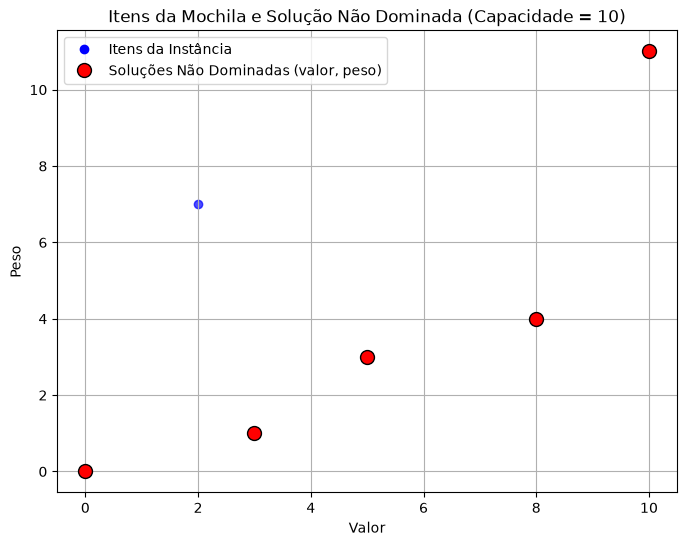

In [4]:
main()

Teste simples de leitura de um trecho do arquivo CSV com apenas 5 registros

--- Processing file: ./instance/knapPI_16_5_1000_teste.csv ---
Total de combinações de itens (bruto 2^N): 32
Quantidade de Pontos Não Dominados (frente de Pareto): 19
Tempo de processamento: 0.0004 segundos


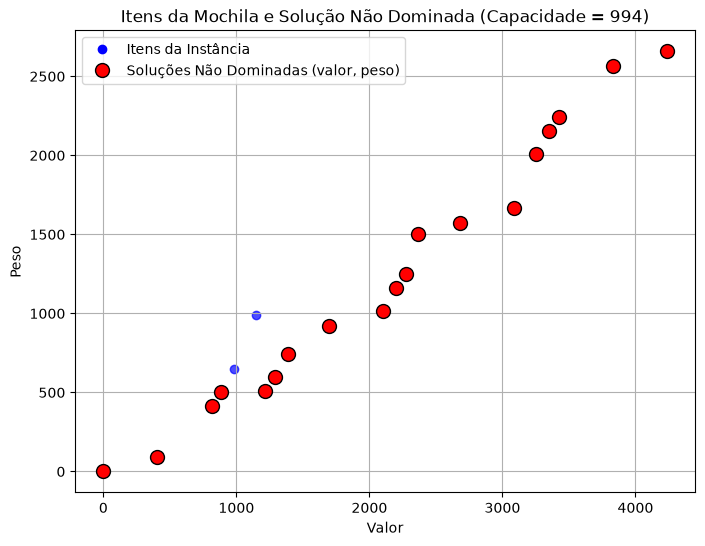

In [7]:
main('./instance/knapPI_16_5_1000_teste.csv')

Teste de um caso do arquivo CSV com 20 registros

--- Processing file: ./instance/knapPI_16_20_1000_teste.csv ---
Total de combinações de itens (bruto 2^N): 1048576
Quantidade de Pontos Não Dominados (frente de Pareto): 530
Tempo de processamento: 44.3192 segundos


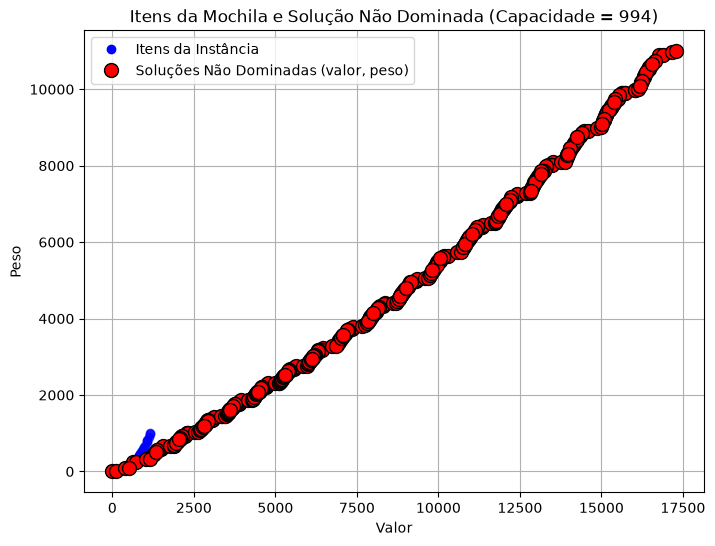

In [8]:
main('./instance/knapPI_16_20_1000_teste.csv')

Teste de um caso do arquivo CSV com 50 registros

In [ ]:
main('./instance/knapPI_16_50_1000_teste.csv')

--- Processing file: ./instance/knapPI_16_50_1000_teste.csv ---


Teste de um caso do arquivo CSV com 100 registros

In [ ]:
main('/content/knapPI_16_100_1000.csv')